In [6]:
from typing import TypedDict,Sequence,Annotated
import operator
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,END,START

from IPython.display import Image, display

In [20]:
class AgentState(TypedDict):
    messages: Annotated[list,operator.add]

def function_1(state):
    return {'messages':['function_1']}


def function_2(state):
    return {'messages':['function_2']}


def function_3(state):
    return {'messages':['function_3']}

In [128]:
graph = StateGraph(AgentState)

graph.add_node('step_1',function_1)
graph.add_node('step_2',function_2)
graph.add_node('step_3',function_3)

graph.add_edge(START,'step_1')
graph.add_edge('step_1','step_2')
graph.add_edge('step_2','step_3')
graph.set_entry_point('step_1')
graph.add_edge('step_3',END)
memory = MemorySaver()
app = graph.compile(checkpointer=memory,interrupt_before=['step_2'])

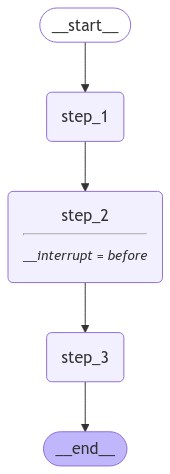

In [129]:
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
state = {'messages':['Hello World']}
thread = {'configurable':{'thread_id':'1'}}

ans=app.invoke(input=state,config=thread,stream_mode='values')


In [29]:
ans

{'messages': ['Hello World', 'function_1', 'function_2']}

In [36]:
thread = {'configurable':{'thread_id':'2'}}
res=app.invoke(input=None,config=thread,stream_mode='values')

In [43]:
app.get_state({'configurable':{'thread_id':'2'}}).next

()

LLM and Tool With Interrupt

In [130]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain.tools import Tool,tool
from langchain_community.tools.tavily_search import TavilySearchResults
import os
import operator

from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langgraph.graph.message import add_messages

In [176]:
class State(TypedDict):
    messages : Annotated[list,add_messages]

os.environ["TAVILY_API_KEY"] = "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"
tavily_tool = TavilySearchResults(max_results=2)

chat_ollama = ChatOllama(model='llama3.2')

llm_tools = chat_ollama.bind_tools(tools=[tavily_tool])

In [177]:
def agent(state):
    print('<-----------Starting Agent---------------->')
    res = llm_tools.invoke(state['messages'])
    # print("response:\n",res)
    return {'messages': [res]}

tool_node = ToolNode(tools=[tavily_tool])

In [178]:
graph=StateGraph(State)

graph.add_node('Agent',agent)
graph.add_node('tools',tool_node)
graph.add_edge('tools','Agent')
graph.set_entry_point('Agent')
graph.add_conditional_edges('Agent',tools_condition)

In [173]:
app = graph.compile(checkpointer=memory,interrupt_before=['tools'])

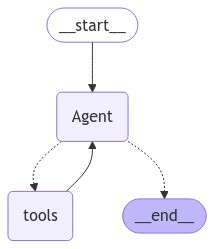

In [174]:
display(Image(app.get_graph().draw_mermaid_png()))

In [157]:
from langchain_core.messages import HumanMessage

state = {'messages':HumanMessage(content='Hello I am Umendra, from Prayag.')}

thread = {'configurable':{'thread_id':'1'}}

for event in app.stream(state,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================ Human Message =================================

Hello I am Umendra, from Prayag.
None
<-----------Starting Agent---------------->
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (f671c7e2-1486-416b-9c45-7e700a83c829)
 Call ID: f671c7e2-1486-416b-9c45-7e700a83c829
  Args:
    query: Umendra from Prayag
None


In [158]:
state = {'messages':HumanMessage(content='WHo is PM of India ?')}

thread = {'configurable':{'thread_id':'1'}}

for event in app.stream(state,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================ Human Message =================================

WHo is PM of India ?
None
<-----------Starting Agent---------------->
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (50072c45-d591-48d1-ba64-d32e3c8dd3c3)
 Call ID: 50072c45-d591-48d1-ba64-d32e3c8dd3c3
  Args:
    query: PM of India
None


In [159]:
for event in app.stream(None,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (50072c45-d591-48d1-ba64-d32e3c8dd3c3)
 Call ID: 50072c45-d591-48d1-ba64-d32e3c8dd3c3
  Args:
    query: PM of India
None
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.pmindia.gov.in/en/pms-profile/", "content": "Shri Narendra Modi was sworn-in as India’s Prime Minister for the third time on 9th June 2024, following another decisive victory in the 2024 Parliamentary elections. The first ever Prime Minister to be born after Independence, Shri Modi has previously served as the Prime Minister of India from 2014 to 2019, and from 2019 to 2024. Leading international agencies have noted that under the leadership of PM Narendra Modi, India has been eliminating poverty at record pace. In June 2024, after assuming office for the third term, one of the first decisions of the Cabinet was

Checkpoint with Custom Tool Call 

In [1]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain.tools import Tool,tool
from langchain_community.tools.tavily_search import TavilySearchResults
import os
import operator

from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel,Field

In [2]:
class AgentState(TypedDict):
    messages : Annotated[list,add_messages]

os.environ["TAVILY_API_KEY"] = "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"
tavily_tool = TavilySearchResults(max_results=2)

chat_ollama = ChatOllama(model='llama3.2')


In [88]:
class structured_output(BaseModel):
    messages: str= Field(description="Categorize the data either into web_search or for_llm ")




prompt = ''' Your task is to strictly categorize the user message into one of the two categories ['web_search', 'for_llm'].
            
             web_search : If user message can be searched over website.
             for_llm : If user messages start with Hi or Hello.
             
             Following is the user message :
             Message : {messages}
'''

template = ChatPromptTemplate.from_template(template=prompt)
llm = ChatOllama(model='llama3.2').with_structured_output(structured_output)
model = template | llm

In [87]:
model.invoke({'messages':'what is the capital of pakistan'})

structured_output(messages='web_search')

In [173]:
result = {}
def Agent(state):
    print('<---------------- Starting Agent ------------------>')
    print('<---------------- State ------------------>\n',state)
    print('<---------------- Message to respond ------------------>\n',state['messages'][-1].content)
    response = model.invoke({'messages':state['messages'][-1].content})
    print('Response:',response)
    # state['messages'].append(response.messages)
    print('<---------------- State ------------------>\n',state['messages'][-1])
    return response

def router(state):
    print('<---------------- Router State ------------------>\n',state)
    response = state['messages']
    print('<---------------- Router ------------------>\n',response[-1].content)
    if response[-1].content=='web_search':
        return 'tools'
    else:
        return 'llm'
    
def llm_response(state):
    print('<-------------- LLM Response --------------->')
    res = chat_ollama.invoke(state['messages'])
    return {'messages':[res.content]}

def tavily_response(state):
    print('<-------------- Tavily Response --------------->',state)
    res = tavily_tool.invoke({'query':state['messages'][-2].content})
    result=res
    print('------Tavily-------',res)
    return {'messages':[res[0].get('content')]}

In [174]:
workflow = StateGraph(AgentState)

workflow.add_node('Agent',Agent)
workflow.add_node('llm',llm_response)
workflow.add_node('tools',tavily_response)

workflow.set_entry_point('Agent')
workflow.add_edge('tools','Agent')
workflow.add_edge('llm','Agent')
workflow.add_conditional_edges('Agent',router,{'llm':'llm','tools':'tools'})

memory = MemorySaver()

app = workflow.compile(checkpointer=memory,interrupt_before=['tools'],interrupt_after=['llm','tools'])

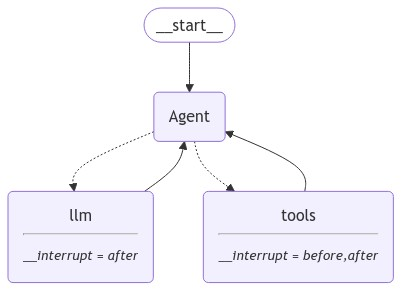

In [175]:
display(Image(app.get_graph().draw_mermaid_png()))

In [176]:
from langchain_core.messages import HumanMessage
state = {'messages':HumanMessage(content='Hi, I am Umendra')}

thread = {'configurable':{'thread_id':'3'}}

for event in app.stream(state,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================ Human Message =================================

Hi, I am Umendra
None
<---------------- Starting Agent ------------------>
<---------------- State ------------------>
 {'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784')]}
<---------------- Message to respond ------------------>
 Hi, I am Umendra
Response: messages='for_llm'
<---------------- State ------------------>
 content='Hi, I am Umendra' id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'
<---------------- Router State ------------------>
 {'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'), HumanMessage(content='for_llm', id='23394018-3686-44c2-a2ce-cfb70a58d675')]}
<---------------- Router ------------------>
 for_llm
================================ Human Message =================================

for_llm
None
<-------------- LLM Response --------------->
================================ Human Message ==========

In [177]:
app.get_state(thread).next

('Agent',)

In [178]:
state = {'messages':[HumanMessage(content='what is the capital of Pakistan ?')]}

thread = {'configurable':{'thread_id':'3'}}

for event in app.stream(state,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================ Human Message =================================

what is the capital of Pakistan ?
None
<---------------- Starting Agent ------------------>
<---------------- State ------------------>
 {'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'), HumanMessage(content='for_llm', id='ac5a901d-9e05-4e50-a249-8d8a97cbad0e'), HumanMessage(content="Hello Umendra! It's nice to meet you. Is there something I can help you with or would you like to chat?", id='ec5a42bb-d9e8-4ba1-a05b-540c59d012b6'), HumanMessage(content='what is the capital of Pakistan ?', id='abba778c-4828-4f09-bbb8-b1336084132f')]}
<---------------- Message to respond ------------------>
 what is the capital of Pakistan ?
Response: messages='web_search'
<---------------- State ------------------>
 content='what is the capital of Pakistan ?' id='abba778c-4828-4f09-bbb8-b1336084132f'
<---------------- Router State ------------------>
 {'messages': [HumanMessa

In [179]:
app.get_state(thread).values

{'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'),
  HumanMessage(content='for_llm', id='ac5a901d-9e05-4e50-a249-8d8a97cbad0e'),
  HumanMessage(content="Hello Umendra! It's nice to meet you. Is there something I can help you with or would you like to chat?", id='ec5a42bb-d9e8-4ba1-a05b-540c59d012b6'),
  HumanMessage(content='what is the capital of Pakistan ?', id='abba778c-4828-4f09-bbb8-b1336084132f'),
  HumanMessage(content='web_search', id='058a2604-835d-425c-942b-24681f423d68')]}

In [180]:
for event in app.stream(None,thread,stream_mode='values'):
    print(event['messages'][-1].pretty_print())

================================ Human Message =================================

web_search
None
<-------------- Tavily Response ---------------> {'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'), HumanMessage(content='for_llm', id='ac5a901d-9e05-4e50-a249-8d8a97cbad0e'), HumanMessage(content="Hello Umendra! It's nice to meet you. Is there something I can help you with or would you like to chat?", id='ec5a42bb-d9e8-4ba1-a05b-540c59d012b6'), HumanMessage(content='what is the capital of Pakistan ?', id='abba778c-4828-4f09-bbb8-b1336084132f'), HumanMessage(content='web_search', id='058a2604-835d-425c-942b-24681f423d68')]}
------Tavily------- [{'url': 'https://ictadministration.gov.pk/history-and-heritage/', 'content': 'The city of Islamabad, the capital of Pakistan, is located on the Pothohar Plateau within the Islamabad Capital Territory—one of the earliest known sites of human settlement in Asia. The capital city of Pakistan, Islamabad is

In [184]:
app.get_state(thread).values

{'messages': [HumanMessage(content='Hi, I am Umendra', id='2ae332f2-ce82-4d46-ae98-8ab602aaa784'),
  HumanMessage(content='for_llm', id='ac5a901d-9e05-4e50-a249-8d8a97cbad0e'),
  HumanMessage(content="Hello Umendra! It's nice to meet you. Is there something I can help you with or would you like to chat?", id='ec5a42bb-d9e8-4ba1-a05b-540c59d012b6'),
  HumanMessage(content='what is the capital of Pakistan ?', id='abba778c-4828-4f09-bbb8-b1336084132f'),
  HumanMessage(content='web_search', id='058a2604-835d-425c-942b-24681f423d68'),
  HumanMessage(content='The city of Islamabad, the capital of Pakistan, is located on the Pothohar Plateau within the Islamabad Capital Territory—one of the earliest known sites of human settlement in Asia. The capital city of Pakistan, Islamabad is located in the northwest of the country on Potohar Plateau. Islamabad is the Capital of the Islamic Republic of Pakistan. The city was built between 1960 – 1970 to replace Karachi as the capital. Karachi had been t